In [1]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs
from matplotlib import pyplot as plt
from utils import draw_tf_heatmap , annotate_region
import dask.dataframe as dd
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region


In [2]:
data_test='cisbp'
inputfolder = '/data2st2/junyi/output/atac1112/tobiasbam/'

In [3]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)
df_important_TF.columns=['TF']
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_2134570/4282565885.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [4]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [5]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)
df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"
dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


/tmp/ipykernel_2134570/747042444.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
/tmp/ipykernel_2134570/747042444.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"


In [6]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

In [7]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [8]:
TOBIAS_Rsults = glob.glob(f'{inputfolder}/*{data_test}*/*.bw/bindetect_results.xlsx')

# Merge all TOBIAS results on TF level

In [9]:
%%capture
# ignore cell outputs for this cell
results = pd.DataFrame()
full = pd.DataFrame()
full_results = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = df_tobias['name'].str.split('#').str[1]
    df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()
    #df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)
    # df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    # df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)
    full_results = pd.concat([full_results, df_tobias], axis=0)
    #results = pd.concat([results, df_expanded_mean], axis=0)

# Vizualize the results as heatmap

In [10]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
        results['log2FC'] = results['MC_MW_change']
    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    else:
        results['ctname'] = results['Region Subclass']
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    if ('FDR' not in results.columns) and ('MC_MW_pvalue' in results.columns):
        results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results


In [11]:
full_results = add_columns(full_results)
#avg_results = add_columns(results)
#full_results_filtered = full_results[full_results['MC_MW_highlighted']==True]
# full_results_filtered = full_results[full_results.FDR < 0.05]
# full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
# full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
# full_results_filtered.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)
#results=avg_results[avg_results.FDR <0.05]
results=full_results[full_results.FDR < 0.05]
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_2134570/971198905.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
/tmp/ipykernel_2134570/971198905.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
/tmp/ipykernel_2134570/971198905.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [12]:
len(results.name.unique())

251

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


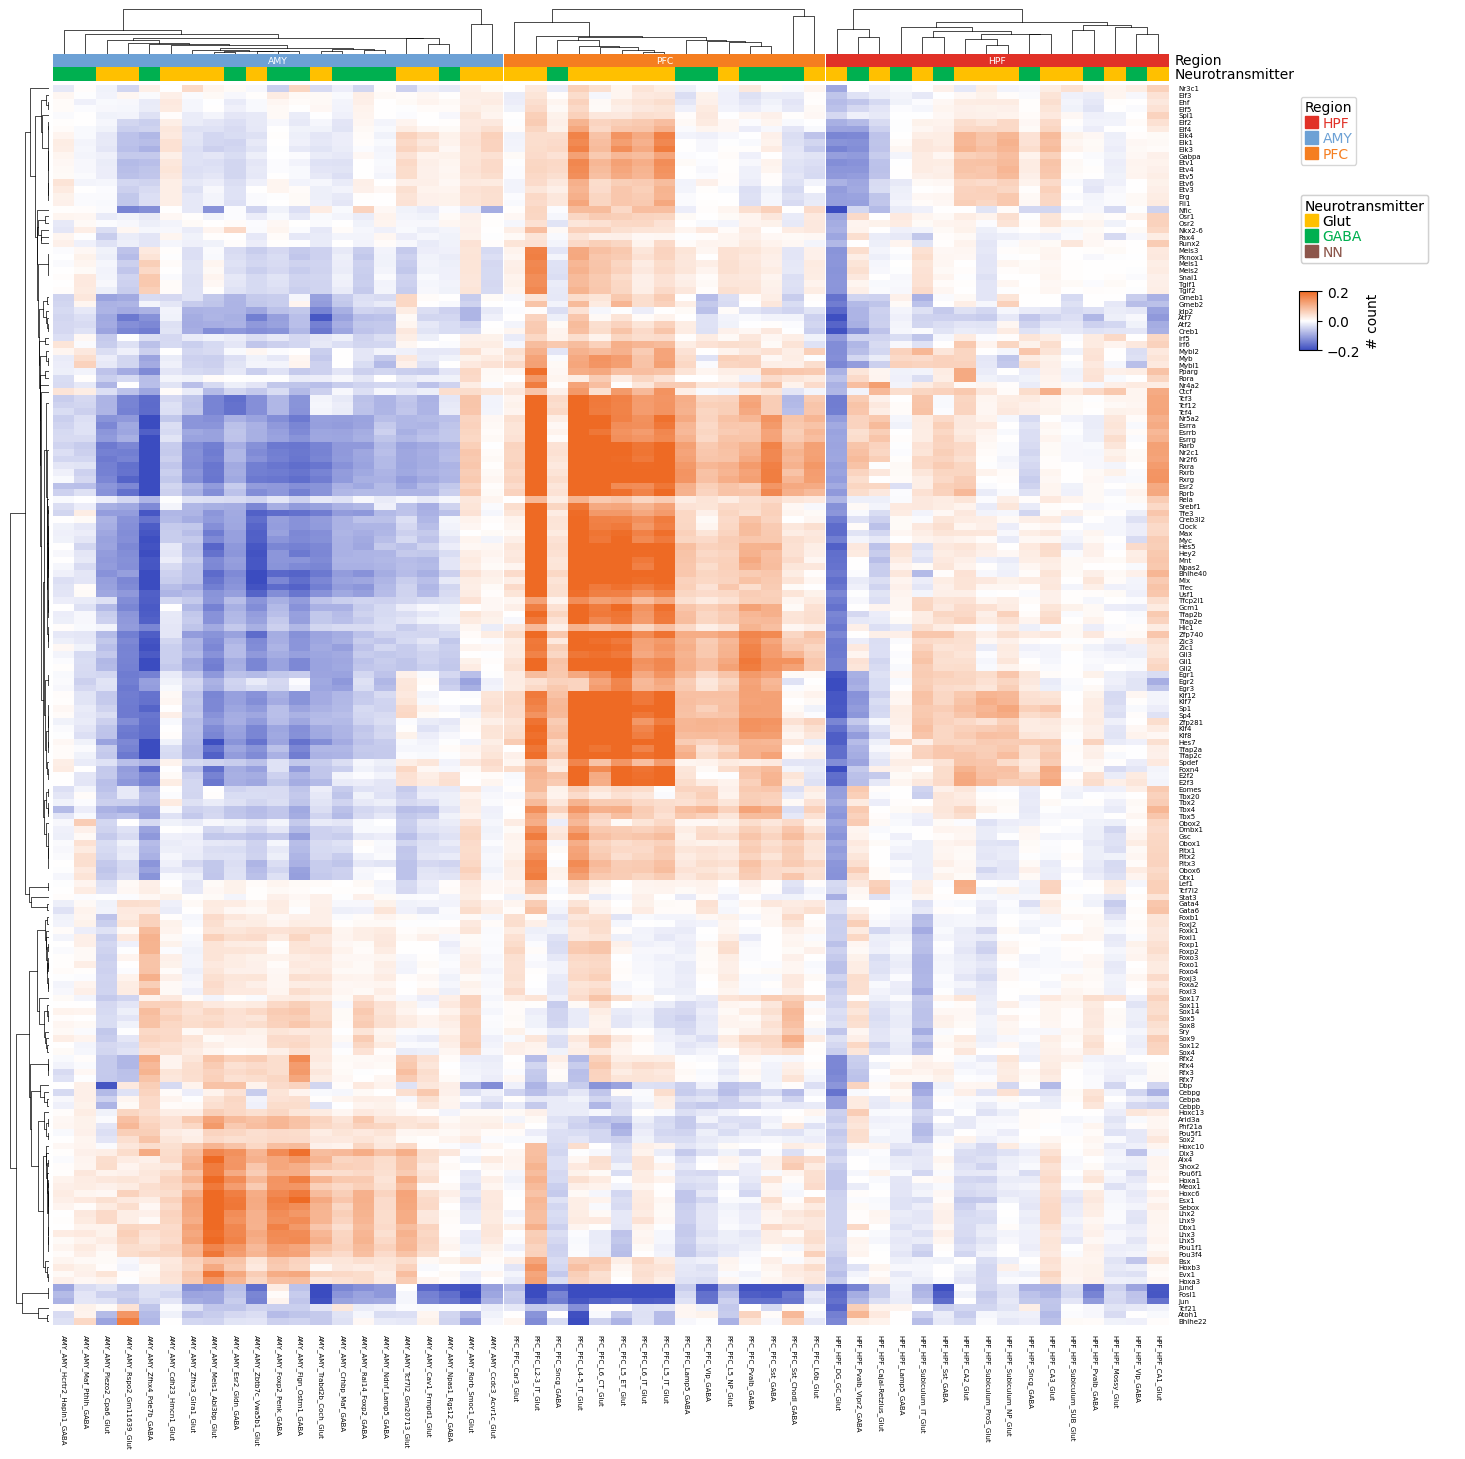

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


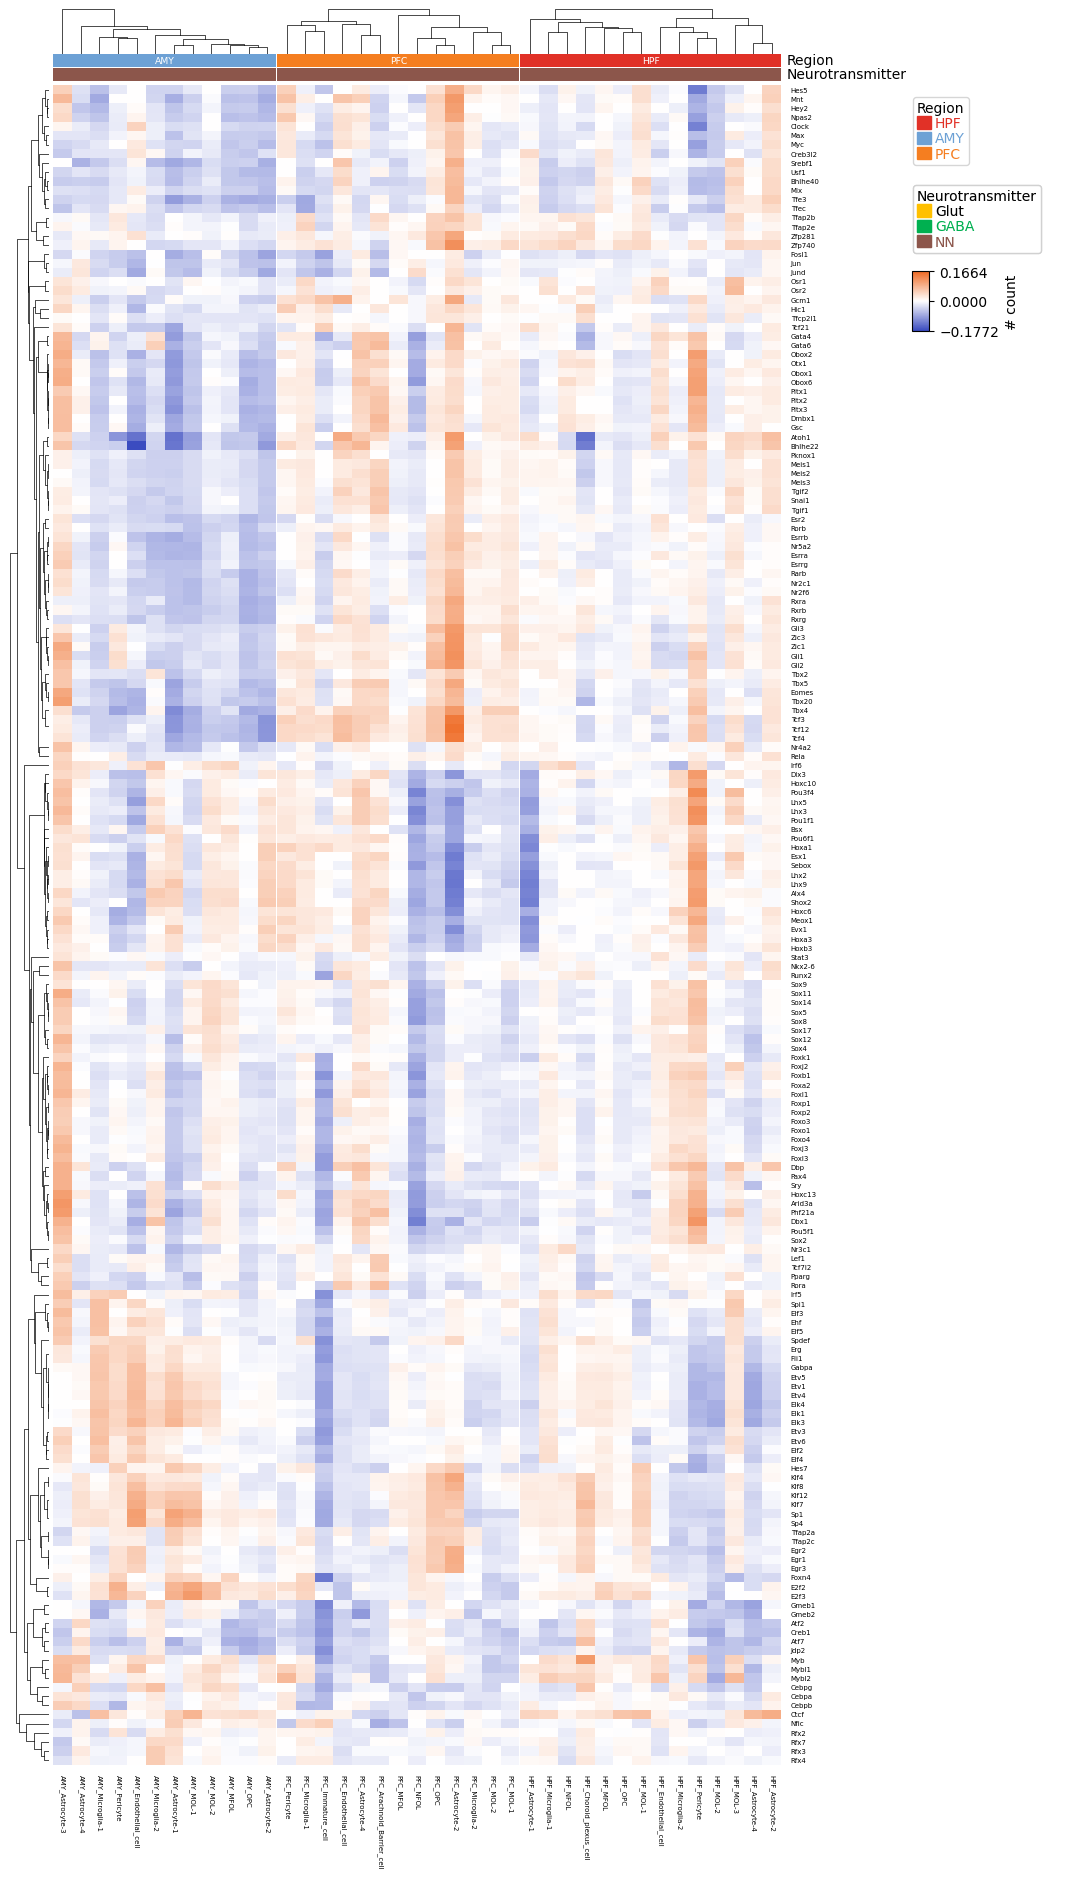

In [13]:

# 修改了 my_module.py 后，重新加载
importlib.reload(utils)

cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(15,15)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_{data_test}.pdf')
cmNN = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC", clipping=100,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_NN_{data_test}.pdf')
# cmavg = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_N_avg.pdf')
# cmavgNN = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN_avg.pdf')
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)
mat=cm.data2d.loc[row_names]
mat.to_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND_mat_{data_test}.csv')
# matavg = cmavg.data2d.loc[list(cmavg.row_order)[0]]
# matavg.to_csv('/data2st1/junyi/output/atac1112/tobias/BIND_matavg.csv')
# denrow = cm.dendrogram_row
# cm.dendrogram_row.dendrogram.keys()
# n = len(cm.dendrogram_row.dendrogram["leaves"])
# k = 10
# labels = np.repeat(np.arange(k), n//k + 1)[:n]

In [14]:
full_selected = full_results[full_results.FDR < 0.05]
full_selected['absLog2FC'] = full_selected['log2FC'].abs()
full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_selected.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

/tmp/ipykernel_2134570/2487230757.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_selected['absLog2FC'] = full_selected['log2FC'].abs()
/tmp/ipykernel_2134570/2487230757.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
/tmp/ipykernel_2134570/2487230757.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

In [15]:
full_selected

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Sex,Gene,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,absLog2FC
213,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,M,Jund,Glut,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.41308
281,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,15462,0.23574,5001,0.20543,4435,0.41225,...,M,Bhlhe40,Glut,PFC_PFC_L2-3_IT_Glut,3.738450e-171,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,0.41225
67,metacluster_64.1cisbp__M00181_None,metacluster_64.1#cisbp__M00181,None,C_metacluster_121.1#cisbp__M02401,39829,0.08652,5737,0.07378,4850,0.40211,...,M,Rxra,Glut,PFC_PFC_L2-3_IT_Glut,3.617700e-187,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,0.40211
7,metacluster_121.1cisbp__M02402_None,metacluster_121.1#cisbp__M02402,None,C_metacluster_121.1#cisbp__M02401,33700,0.09652,5415,0.08287,4641,0.39166,...,M,Rxrb,Glut,PFC_PFC_L2-3_IT_Glut,1.402270e-182,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,0.39166
5,metacluster_121.1cisbp__M02400_None,metacluster_121.1#cisbp__M02400,None,C_metacluster_121.1#cisbp__M02401,32135,0.09680,5130,0.08338,4400,0.39026,...,M,Rxrg,Glut,PFC_PFC_L2-3_IT_Glut,6.018280e-183,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,0.39026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,metacluster_118.1cisbp__M00439_None,metacluster_118.1#cisbp__M00439,None,C_metacluster_118.1#cisbp__M00380,2425,2.12368,112,3.74010,220,0.00024,...,M,Shox2,NN,HPF_MOL-3,3.564320e-02,MOL-3,HPF,Up,MOL-3,0.00024
224,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,M,E2f3,NN,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,0.00012
326,metacluster_142.2cisbp__M08042_None,metacluster_142.2#cisbp__M08042,None,C_metacluster_142.2#cisbp__M08031,37314,0.18162,21632,0.18229,22521,0.00011,...,M,Sox2,NN,AMY_Astrocyte-2,1.942390e-02,Astrocyte-2,AMY,Up,Astrocyte-2,0.00011
143,metacluster_188.5cisbp__M00163_None,metacluster_188.5#cisbp__M00163,None,C_metacluster_188.5#cisbp__M00163,13760,0.44908,1573,0.43975,1585,-0.00008,...,M,Foxk1,Glut,HPF_HPF_Subiculum_SUB_Glut,1.663650e-02,HPF_Subiculum_SUB_Glut,HPF,Down,HPF_Subiculum_SUB_Glut,0.00008


# Region level analysis

In [16]:
df_regions = pd.DataFrame()
valid_files = []
unvalid_files = []
for idx, row in full_selected.iterrows():
    prefix = row['output_prefix']
    region = row['Region'].replace('HPF','HIP')
    subclass = row['Subclass']
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MC_bound.bed'
    #downbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MW_bound.bed'
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'
    upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'

    # df_t = pd.read_csv(upbed, sep='\t')
    # df_t['TF'] = row['TF']
    # df_t['Region Subclass'] = row['Region Subclass']
    # df_regions = pd.concat([df_regions, df_t], axis=0)
    if os.path.exists(upbed):
        valid_files.append(upbed)
    else:
        unvalid_files.append(upbed)
    # if os.path.exists(downbed):
    #     valid_files.append(downbed)
    # else:
    #     unvalid_files.append(downbed)

In [17]:
df = dd.read_csv(valid_files, sep='\t', header=0,include_path_column="source_file")
#df.columns = ['chr','start','end','name','score','strand','peak_chr','peak_start','peak_end','bound','source_file']

In [18]:
df_filtered = df[(df['MC_bound']>0) | (df['MW_bound']>0)]
df_filtered['absLog2FC']  = df_filtered['MC_MW_log2fc'].abs()
df_filtered['Region Subclass'] = df_filtered['source_file'].str.split('/').str[7].str[:-17]
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HIP','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HPF_HPF','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('AMY_AMY','AMY')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('PFC_PFC','PFC')
df_filtered['names'] = df_filtered['peak_chr'].astype(str)+':'+df_filtered['peak_start'].astype(str)+'-'+df_filtered['peak_end'].astype(str)
df_filtered['Direction'] = df_filtered['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/dask/dataframe/core.py:4158: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('MC_MW_log2fc', 'object'))

  warnings.warn(meta_warning(meta))


In [19]:
df_regions= df_filtered.compute()

In [20]:
df_regions.shape

(95584398, 19)

In [21]:
df_db=pd.read_feather("/data2st1/junyi/scenic/mouse/motif/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather")

In [22]:
dict_tfbs2tf = dict(zip(df_direct_annot['TFBS_name'], df_direct_annot['TF']))

In [23]:
df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [24]:
df_regions.head(1000)

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,MW_score,MC_bound,MW_bound,MC_MW_log2fc,source_file,absLog2FC,Region Subclass,names,Direction,TF
5,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,0.21381,0,1,-0.76929,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.76929,PFC_L4-5_IT_Glut,chr1:3309937-3310438,Down,Jund
16,chr1,3457981,3457990,metacluster_137.2cisbp__M01001_None,9.27677,-,chr1,3457706,3458207,0.43410,0.72141,1,1,-0.70336,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down,Jund
30,chr1,5070452,5070461,metacluster_137.2cisbp__M01001_None,8.38934,-,chr1,5070169,5070670,0.58746,0.66948,1,1,-0.18182,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.18182,PFC_L4-5_IT_Glut,chr1:5070169-5070670,Down,Jund
33,chr1,5208333,5208342,metacluster_137.2cisbp__M01001_None,8.59528,+,chr1,5208069,5208570,0.21343,0.25563,1,1,-0.23676,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.23676,PFC_L4-5_IT_Glut,chr1:5208069-5208570,Down,Jund
38,chr1,6054357,6054366,metacluster_137.2cisbp__M01001_None,8.38934,-,chr1,6054101,6054602,0.09268,0.17249,0,1,-0.75600,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.75600,PFC_L4-5_IT_Glut,chr1:6054101-6054602,Down,Jund
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4056,chr10,60405709,60405718,metacluster_137.2cisbp__M01001_None,8.15123,-,chr10,60405403,60405904,0.12431,0.26791,0,1,-0.98081,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.98081,PFC_L4-5_IT_Glut,chr10:60405403-60405904,Down,Jund
4058,chr10,60685702,60685711,metacluster_137.2cisbp__M01001_None,8.59528,+,chr10,60685418,60685919,0.07447,0.28054,0,1,-1.63697,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,1.63697,PFC_L4-5_IT_Glut,chr10:60685418-60685919,Down,Jund
4063,chr10,60934527,60934536,metacluster_137.2cisbp__M01001_None,8.80971,+,chr10,60934260,60934761,0.36049,0.65503,1,1,-0.82185,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.82185,PFC_L4-5_IT_Glut,chr10:60934260-60934761,Down,Jund
4067,chr10,61146213,61146222,metacluster_137.2cisbp__M01001_None,8.27965,+,chr10,61146041,61146542,0.14307,0.21591,0,1,-0.52418,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.52418,PFC_L4-5_IT_Glut,chr10:61146041-61146542,Down,Jund


In [25]:
for condition in ['MW','MC']:

    df_regions[df_regions['Region Subclass']=='PFC_L4-5_IT_Glut'].shape

In [92]:
df_regions_f = df_regions#[df_regions['absLog2FC'] >= 0.1]
# df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [93]:
df_regions_f.shape

(95584398, 20)

In [83]:
df_annoated = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/cCRE_annotated.csv')

In [28]:
#df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv')

In [29]:
# df_Group = df_regions_f.groupby(['names', 'Region Subclass','Direction'], as_index=False).agg(
#     combined_TF=('TF', lambda x: '/'.join(x.astype(str))),
#     combined_TFBS=('TFBS_name', lambda x: '/'.join(x.astype(str)))
# )


In [95]:
df_merged_region = pd.merge(df_regions_f,df_annoated,how='inner',on='names')

In [96]:
df_merged_region.to_parquet('/data2st1/junyi/output/atac1112/tobias/annotated.parquet', engine='pyarrow')  # or engine='fastparquet'


In [97]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,gend,strand,annotation_x,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
1,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.14157,-,chr1,3309937,3310438,0.11586,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
2,chr1,3309945,3309956,metacluster_137.2cisbp__M01805_None,8.69334,-,chr1,3309937,3310438,0.11586,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
3,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.29504,-,chr1,3309937,3310438,0.36816,...,3671498,-,genebody,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438


In [31]:
df_deg = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/mast_ngsa_noco_degs_fdr_log2fc0_filtered.csv")
df_deg['Region Subclass'] = df_deg['Region subclass'].str.replace(" ",'_')
df_deg['Region Subclass'] = df_deg['Region Subclass'].str.replace("/",'-')
df_deg = df_deg[df_deg.Sex=='M']
df_deg = df_deg[df_deg.Region.isin(['HPF','PFC','AMY'])]

In [33]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,gend,strand,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene,absdistance
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0
1,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.14157,-,chr1,3309937,3310438,0.11586,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0
2,chr1,3309945,3309956,metacluster_137.2cisbp__M01805_None,8.69334,-,chr1,3309937,3310438,0.11586,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0
3,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.29504,-,chr1,3309937,3310438,0.36816,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0


In [34]:
# for TF in df_test_TF_gene['TF'].unique():
#     df_tf = df_test_TF_gene[df_test_TF_gene['TF'] == TF]
#     concordant = sum(df_tf['Direction_deg'] == df_tf['Direction_tobias'])
#     total = df_tf.shape[0]
#     concordance_rate = concordant / total
#     print(f'TF: {TF}, Concordance Rate: {concordance_rate:.2f} ({concordant}/{total})')

In [35]:
def archr_distance_weight(d):
    d = abs(d)
    return np.exp(-d/5000) + np.exp(-1)

def copute_weighted_score(df_input):
    df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
    df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
    df_input["MW_Weighted"] = df_input["MW_score"] * df_input["distance_weight"]
    df_trimed = df_input[(df_input.distance <= 100000) & (df_input.distance >= -100000)]
    df_trimed_grouped =  df_trimed.groupby(['gene_name','Region Subclass']).sum().reset_index()
    df_trimed_grouped['log2FC'] = np.log2((df_trimed_grouped['MC_Weighted'] + 1e-10) / (df_trimed_grouped['MW_Weighted'] + 1e-10))
    df_trimed_grouped['Region subclass'] = df_trimed_grouped['Region Subclass']
    #Direction	Region	Neurotransmitter	Sex	Gene	Subclass
    df_trimed_grouped['Direction'] = df_trimed_grouped['log2FC'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_trimed_grouped['Sex'] = 'M'
    df_trimed_grouped['Gene'] = df_trimed_grouped['gene_name']
    df_trimed_grouped['Neurotransmitter'] = df_trimed_grouped['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    df_trimed_grouped['Subclass'] = df_trimed_grouped['Region Subclass']
    df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'] = df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'].str[4:]
    df_trimed_grouped['Region'] = df_trimed_grouped['Region Subclass'].str[:3].str.replace('HIP','HPF')
    return df_trimed_grouped

In [36]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None,showplot=False,set_labels=("Tobias", "deg")):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2['Gene']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = set_labels)
    if showplot:
        plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

In [37]:
IoUs= []
TFs = []
pctDEG = []
for TF in df_merged_region.TF.unique():
    df_TF_jun = df_merged_region[df_merged_region.TF==TF]
    df_TF_jun_wg = copute_weighted_score(df_TF_jun)
    set1,set2 = draw_venndiagram(df_TF_jun, df_deg,savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{TF}_tobias_deg.pdf')
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    iou = len(intersection) / len(union) if len(union) > 0 else 0
    IoUs.append(iou)
    TFs.append(TF)
    pctDEG.append(len(intersection)/len(set2) if len(set2)>0 else 0)

/tmp/ipykernel_2134570/3602613066.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
/tmp/ipykernel_2134570/3602613066.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
/tmp/ipykernel_2134570/3602613066.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [38]:
df_results= pd.DataFrame({'TF':TFs, 'IoU':IoUs})

In [39]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated_with_TFs.csv')
df_DAR['distance_weight'] = df_DAR['distance'].apply(archr_distance_weight)
df_DAR["log2FC_Weighted"] = df_DAR["log2FC"] * df_DAR["distance_weight"]


In [40]:
df_merged_region['Region'] = df_merged_region['Region Subclass'].str[:3].str.replace('HIP','HPF')

In [41]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,strand,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene,absdistance,Region
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
1,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.14157,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
2,chr1,3309945,3309956,metacluster_137.2cisbp__M01805_None,8.69334,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
3,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,HPF
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.29504,-,chr1,3309937,3310438,0.36816,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,HPF


In [42]:
df_DAR['TFs'] = df_DAR['TFs'].str.split('/')

In [43]:
df_DAR_expanded = df_DAR.explode('TFs').reset_index(drop=True)

In [ ]:
Yfrom matplotlib import cm
def show_stacked_barplot(df_DAR,column_status="primary_region",direction_col="Direction",title='',save=False):
    df = df_DAR.copy()
    # Aggregate
    up_df = df[df[direction_col] == "Up"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    down_df = df[df[direction_col] == "Down"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)

    # Down values become negative
    down_df = -down_df

    # Unified color palette for primary regions
    categories = up_df.columns
    cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.
    colors = {cat: cmap(i) for i, cat in enumerate(categories)}


    plt.figure(figsize=(18,8))

    # ----- Plot Up (positive) -----
    bottom_up = None
    for region in up_df.columns:
        plt.bar(
            up_df.index,
            up_df[region],
            bottom=bottom_up,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3,
            label=region if bottom_up is None else ""
        )
        bottom_up = up_df[region] if bottom_up is None else bottom_up + up_df[region]

    # ----- Plot Down (negative) -----
    bottom_down = None
    for region in down_df.columns:
        plt.bar(
            down_df.index,
            down_df[region],
            bottom=bottom_down,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3
        )
        bottom_down = down_df[region] if bottom_down is None else bottom_down + down_df[region]

    # Formatting
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.ylabel("Count")
    plt.title(title)

    # SINGLE legend (only regions)
    handles = [plt.Rectangle((0,0),1,1,color=colors[r]) for r in up_df.columns]
    plt.legend(handles, up_df.columns, bbox_to_anchor=(1.02,1), loc='upper left', title="Primary Region")

    plt.tight_layout()
    if save:
        plt.savefig(save,dpi=300)
    else:
        plt.show()


In [45]:
df_DAR_expanded['absLog2FC'] = df_DAR_expanded['log2FC_Weighted'].abs()
df_DAR_expanded.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
df_DAR_expanded.drop_duplicates(subset=['TFs','Region Subclass','names','status'],inplace=True)

In [46]:
df_DAR_expanded['TF']= df_DAR_expanded['TFs']

In [47]:
df_DAR['Gene'] = df_DAR['gene_name']

In [48]:
df_DAR

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Direction,Neurotransmitter,Gene_name,FDR,Region Subclass Direction,TFs,motifs,method,distance_weight,log2FC_Weighted
0,chr10:100456562-100457063,1.414898e-02,-0.006031,0.006165,-0.018226,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.751694e-02,...,Down,Glut,chr10:100456562-100457063,2.751694e-02,HPF_CA3_Glut_Down,NaN,NaN,NaN,1.367879,-0.008249
1,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,Up,Glut,chr10:100487209-100487710,9.867574e-08,HPF_CA3_Glut_Up,"[2610021A01Rik, Cnot3, Creb1, E2f1, E2f3, E2f4...",hdpi__ELF2/dbtfbs__E2F8_representative_N1/meta...,MASTNG,1.367879,0.093303
2,chr10:100487209-100487710,1.702931e-10,0.068210,0.093457,0.042963,0.000006,HPF_CA3_Glut,HPF,HPF_CA3_Glut,9.867574e-08,...,Up,Glut,chr10:100487209-100487710,9.867574e-08,HPF_CA3_Glut_Up,"[2610021A01Rik, Cnot3, Creb1, E2f1, E2f3, E2f4...",hdpi__ELF2/dbtfbs__E2F8_representative_N1/meta...,MASTNG,1.367879,0.093303
3,chr10:100642797-100643298,6.163128e-03,-0.014478,-0.004093,-0.024864,1.000000,HPF_CA3_Glut,HPF,HPF_CA3_Glut,1.490774e-02,...,Down,Glut,chr10:100642797-100643298,1.490774e-02,HPF_CA3_Glut_Down,"[2610021A01Rik, Gm28168, Gm28360, Gm7145, Kat7...",metacluster_151.1,MASTNG,0.556805,-0.008062
4,chr10:10107158-10107659,5.303556e-07,0.030881,0.045954,0.015808,0.017210,HPF_CA3_Glut,HPF,HPF_CA3_Glut,2.347109e-05,...,Up,Glut,chr10:10107158-10107659,2.347109e-05,HPF_CA3_Glut_Up,"[En1, Spdef]",metacluster_191.5/transfac_public__M00396,MASTNG,1.367879,0.042241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334132,chr7:99535252-99535753,4.700413e-06,0.001785,0.060391,-0.056820,0.079099,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,1.977464e-02,...,Up,GABA,chr7:99535252-99535753,1.977464e-02,AMY_Npas1_Rgs12_GABA_Up,"[Ahr, Arnt, E2f2, E2f3, E2f6, Egr1, Elf2, Elf3...",hdpi__NRL/swissregulon__hs__AHR/transfac_pro__...,MASTNG,1.367879,0.002442
334133,chr9:103365644-103366145,8.286317e-05,0.028069,0.108636,-0.052498,1.000000,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,4.904168e-02,...,Up,GABA,chr9:103365644-103366145,4.904168e-02,AMY_Npas1_Rgs12_GABA_Up,NaN,NaN,NaN,1.367879,0.038395
334134,chr9:99436435-99436936,3.917479e-05,-0.054067,-0.014330,-0.093805,0.659233,AMY_Npas1_Rgs12_GABA,AMY,AMY_Npas1_Rgs12_GABA,3.488255e-02,...,Down,GABA,chr9:99436435-99436936,3.488255e-02,AMY_Npas1_Rgs12_GABA_Down,"[Atf1, Atf2, Atf3, Atf4, Atf7, Creb1, Crem, Eh...",dbtfbs__E2F8_representative_N1/transfac_pro__M...,MASTNG,1.367879,-0.073957
334135,chr13:43171217-43171718,2.009124e-06,NaN,NaN,NaN,0.018430,PFC_Sst_Chodl_GABA,PFC,PFC_Sst_Chodl_GABA,1.842970e-02,...,Down,GABA,chr13:43171217-43171718,1.842970e-02,PFC_Sst_Chodl_GABA_Down,"[Atf2, E4f1, Elk1, Elk3, Elk4, Epas1, Erg, Ets...",taipale_tf_pairs__CLOCK_FIGLA_NCASSTGKNNNNNNNN...,MASTNG,1.367879,NaN


In [49]:
df_DAR['absLog2FC'] = df_DAR['log2FC'].abs()

In [50]:
df_DAR_expanded['Gene'] = df_DAR_expanded['gene_name']
df_merged_region['Gene'] = df_merged_region['gene_name']

In [51]:
df_DAR_expanded.head()

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Gene_name,FDR,Region Subclass Direction,TFs,motifs,method,distance_weight,log2FC_Weighted,absLog2FC,TF
6229204,chr6:103648953-103649454,1.910131e-05,1.466141,1.920083,1.012200,2.895758e-02,Ependymal_cell,HPF,HPF_Ependymal_cell,2.895758e-02,...,chr6:103648953-103649454,2.895758e-02,HPF_Ependymal_cell_Up,NaN,NaN,NaN,1.367879,2.005505,2.005505,NaN
8238955,chr2:98666919-98667420,1.786185e-24,1.034066,1.216309,0.851823,3.068666e-20,AMY_Tcf7l2_Gm20713_Glut,AMY,AMY_Tcf7l2_Gm20713_Glut,3.068666e-20,...,chr2:98666919-98667420,3.068666e-20,AMY_Tcf7l2_Gm20713_Glut_Up,NaN,NaN,NaN,1.367879,1.414478,1.414478,NaN
4745876,chr2:98666919-98667420,2.625773e-98,0.859369,0.935932,0.782806,4.145570e-94,AMY_Zfhx4_Pde7b_GABA,AMY,AMY_Zfhx4_Pde7b_GABA,4.145570e-94,...,chr2:98666919-98667420,4.145570e-94,AMY_Zfhx4_Pde7b_GABA_Up,NaN,NaN,NaN,1.367879,1.175513,1.175513,NaN
2086102,chr2:98666919-98667420,3.499952e-12,0.835068,1.076561,0.593574,5.464125e-08,MOL-2,AMY,AMY_MOL.2,5.464125e-08,...,chr2:98666919-98667420,5.464125e-08,AMY_MOL-2_Up,NaN,NaN,NaN,1.367879,1.142272,1.142272,NaN
4226553,chr2:98666919-98667420,4.452674e-30,0.726474,0.842969,0.609978,5.879756e-26,PFC_Vip_GABA,PFC,PFC_Vip_GABA,5.879756e-26,...,chr2:98666919-98667420,5.879756e-26,PFC_Vip_GABA_Up,NaN,NaN,NaN,1.367879,0.993729,0.993729,NaN


In [52]:
df_DAR['TF'] = df_DAR['TFs']

In [53]:
# PEARSON R
from scipy.stats import pearsonr, spearmanr
def summerize_correlation(df, col1, col2):
    corrs = {}
    pvales = {}
    for tf in df['TF'].unique():
        df_tf = df[df['TF'] == tf]
        corr_value = spearmanr(df_tf[col1], df_tf[col2])[0]
        corr_p = spearmanr(df_tf[col1], df_tf[col2])[1]
        corrs[tf] = corr_value
        pvales[tf] = corr_p
    return corrs, pvales

In [54]:
df_merged_region['tobias_log2FC'] = df_merged_region['MC_MW_log2fc']
df_DAR_expanded.rename(columns={'log2FC':'DAR_log2FC'}, inplace=True)

In [55]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene,absdistance,Region,tobias_log2FC
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,0,PFC,-0.76929
1,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.14157,-,chr1,3309937,3310438,0.11586,...,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,0,PFC,-0.76929
2,chr1,3309945,3309956,metacluster_137.2cisbp__M01805_None,8.69334,-,chr1,3309937,3310438,0.11586,...,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,0,PFC,-0.76929
3,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,0,HPF,-1.05601
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.29504,-,chr1,3309937,3310438,0.36816,...,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,Xkr4,0,HPF,-1.05601


/tmp/ipykernel_2134570/546395164.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
/tmp/ipykernel_2134570/546395164.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deg_merge_proxima_unique['TF_gene'] = df_deg_merge_proxima_unique['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
/tmp/ipykernel_2134570/546395164.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

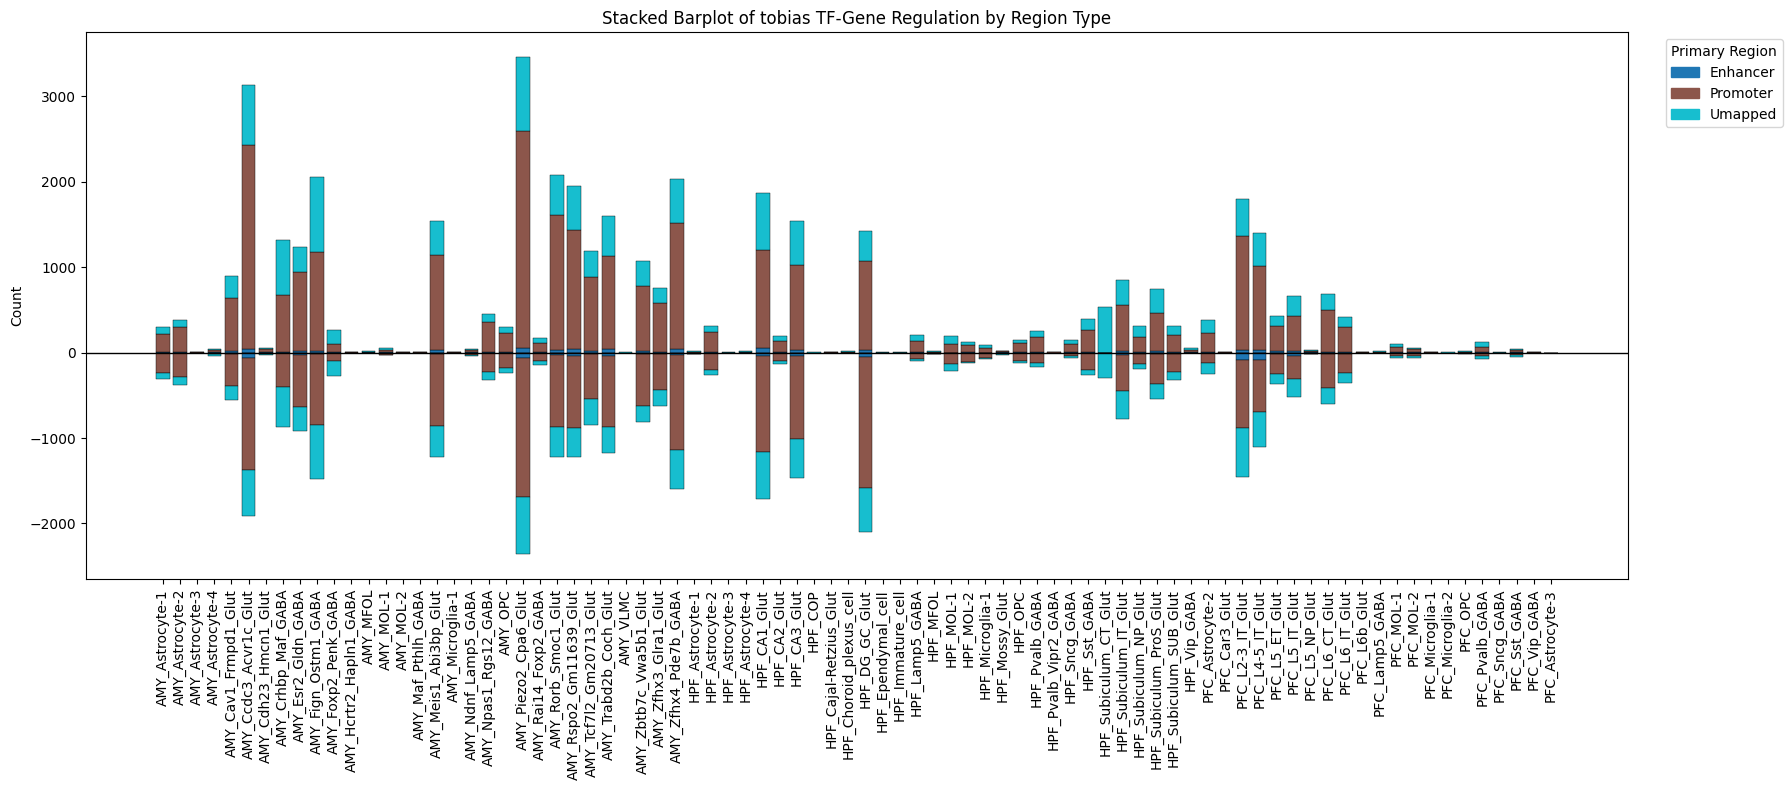

In [56]:
result_dict = {}
for exp, df_tmp_all in [("tobias", df_merged_region)]:#,("tobias", df_merged_region) #('DAR',df_DAR_expanded)

    df_tmp_promoter = df_tmp_all[df_tmp_all['primary_region']=='promoter']
    df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
    df_unq = df_tmp_promoter.drop_duplicates(subset=['gene_name','Region Subclass','TF','Direction'])
    #df_unq = df_tmp_promoter
    df_deg_merge = pd.merge(df_unq, df_deg, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                     suffixes=('_promoter','_deg'),indicator='promoter')
    df_deg_merge_gene = df_deg_merge.drop_duplicates(subset=['Region Subclass','Gene','Direction'])
    #df_deg_merge_gene = df_deg_merge
    df_deg_merge_promoter = df_deg_merge_gene[df_deg_merge_gene['promoter']=='both']
    df_deg_merge_nomap = df_deg_merge_gene[df_deg_merge_gene['promoter']=='right_only']

    df_deg_merge_nomap = df_deg_merge_nomap.dropna(axis=1)
    df_near_proximal = df_tmp_all[(df_tmp_all['primary_region']=='distal')]
    df_deg_merge_proxima = pd.merge(df_near_proximal, df_deg_merge_nomap, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                        suffixes=('_prx','_degn'),indicator='nearproximal')
    


    df_deg_merge_proxima_unique = df_deg_merge_proxima.drop_duplicates(subset=['Region Subclass','Gene','Direction'])
    df_deg_merge_proxima_unique['TF_gene'] = df_deg_merge_proxima_unique['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
    df_deg_merge_promoter['TF_gene'] = 'Promoter'
    df_promoter_final = df_deg_merge_promoter[['Gene','Region Subclass','Direction','TF_gene']]
    df_enhancer_final = df_deg_merge_proxima_unique[['Gene','Region Subclass','Direction','TF_gene']]
    df_grn_final = pd.concat([df_promoter_final, df_enhancer_final], axis=0)
    show_stacked_barplot(df_grn_final, column_status="TF_gene", title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_tf_gene_regiontype.pdf')

    df_deg_merge_promoter_size = df_deg_merge_promoter.groupby(['TF','Region Subclass']).size().reset_index()
    df_deg_pro_select = df_deg_merge_promoter_size[df_deg_merge_promoter_size[0]>10]
    df_deg_merge_promoter_5 = df_deg_merge_promoter.merge(df_deg_pro_select[['TF','Region Subclass']], how='inner', on=['TF','Region Subclass'])
    df_corr, df_pval = summerize_correlation(df_deg_merge_promoter_5, f'{exp}_log2FC', 'log2FC')
    df_corr = pd.DataFrame(list(df_corr.items()), columns=['TF', 'correlation'])
    df_pval = pd.DataFrame(list(df_pval.items()), columns=['TF', 'pvalue'])
    df_corr_pval = pd.merge(df_corr, df_pval, how='inner', on='TF')
    df_corr_pval.to_csv(f'/data2st1/junyi/output/atac1112/tobias/testdeg/correlation_{exp}_tf_gene_promoter.csv', index=False)  


In [57]:
df_deg_merge_proxima.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Subclass,Region_deg,Sex_deg,Method,Ensemble_deg,Gene_name,Neurotransmitter,Region subclass,promoter,nearproximal
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000084925,"""1810062O18Rik""",NN,PFC Astrocyte-2,right_only,right_only
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000087259,"""2610035D17Rik""",NN,PFC Astrocyte-2,right_only,right_only
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000097071,"""4930544I03Rik""",NN,PFC Astrocyte-2,right_only,right_only
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000115337,"""4930570B17Rik""",NN,PFC Astrocyte-2,right_only,right_only
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000039851,"""4932438H23Rik""",NN,PFC Astrocyte-2,right_only,right_only


In [58]:
# for exp, df_tmp_all in [("tobias", df_merged_region)]:#,("tobias", df_merged_region) #('DAR',df_DAR_expanded)

#     df_tmp_promoter = df_tmp_all[df_tmp_all['primary_region']=='promoter']
#     df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
#     df_unq = df_tmp_promoter.drop_duplicates(subset=['gene_name','Region Subclass','TF'])
#     df_deg_merge = pd.merge(df_unq, df_deg, how='right', left_on=['Region Subclass','Gene'], right_on=['Region Subclass','Gene'],
#                      suffixes=('_promoter','_deg'),indicator='promoter')
#     df_deg_merge_gene = df_deg_merge.drop_duplicates(subset=['Region Subclass','Gene'])
#     df_deg_merge_promoter = df_deg_merge_gene[df_deg_merge_gene['promoter']=='both']
#     df_deg_merge_nomap = df_deg_merge_gene[df_deg_merge_gene['promoter']=='right_only']

#     df_deg_merge_nomap = df_deg_merge_nomap.dropna(axis=1)
#     df_near_proximal = df_tmp_all[(df_tmp_all['primary_region']=='distal')]
#     df_deg_merge_proxima = pd.merge(df_near_proximal, df_deg_merge_nomap, how='right', left_on=['Region Subclass','Gene'], right_on=['Region Subclass','Gene'],
#                         suffixes=('_prx','_degn'),indicator='nearproximal')

#     df_deg_merge_proxima_unique = df_deg_merge_proxima.drop_duplicates(subset=['Region Subclass','Gene'])
#     df_deg_merge_proxima_unique['TF_gene'] = df_deg_merge_proxima_unique['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
#     df_deg_merge_promoter['TF_gene'] = 'Promoter'
#     df_promoter_final = df_deg_merge_promoter[['Gene','Region Subclass','TF_gene']]
#     df_enhancer_final = df_deg_merge_proxima_unique[['Gene','Region Subclass','TF_gene']]
#     df_grn_final = pd.concat([df_promoter_final, df_enhancer_final], axis=0)
#     #show_stacked_barplot(df_grn_final, column_status="TF_gene", title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type',save=f'/data2st1/junyi/output/atac1112/tobias/testdeg/stackedbar_{exp}_tf_gene_regiontype.pdf')


In [59]:
df_deg_merge_proxima.dropna()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Subclass,Region_deg,Sex_deg,Method,Ensemble_deg,Gene_name,Neurotransmitter,Region subclass,promoter,nearproximal
165,chr1,92216290.0,92216299.0,metacluster_192.2cisbp__M01660_None,6.61831,-,chr1,92215938.0,92216439.0,0.60120,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000026313,"""Hdac4""",NN,PFC Astrocyte-2,right_only,both
203,chr3,17786086.0,17786101.0,metacluster_133.2cisbp__M08025_None,6.36574,+,chr3,17786009.0,17786510.0,1.32104,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000100252,"""Mir124-2hg""",NN,PFC Astrocyte-2,right_only,both
204,chr3,17786139.0,17786154.0,metacluster_133.2cisbp__M08025_None,13.22105,-,chr3,17786009.0,17786510.0,2.22942,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000100252,"""Mir124-2hg""",NN,PFC Astrocyte-2,right_only,both
205,chr3,17786143.0,17786153.0,metacluster_195.2cisbp__M00133_None,7.96284,-,chr3,17786009.0,17786510.0,2.22942,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000100252,"""Mir124-2hg""",NN,PFC Astrocyte-2,right_only,both
206,chr3,17786086.0,17786116.0,metacluster_24.2cisbp__M08038_None,14.59869,+,chr3,17786009.0,17786510.0,1.32104,...,Astrocyte-2,PFC,M,MAST,ENSMUSG00000100252,"""Mir124-2hg""",NN,PFC Astrocyte-2,right_only,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46704,chr14,19987235.0,19987245.0,metacluster_136.3cisbp__M00823_None,7.62877,+,chr14,19987007.0,19987508.0,0.87273,...,OPC,AMY,M,MAST,ENSMUSG00000043004,"""Gng2""",NN,AMY OPC,right_only,both
46705,chr14,19985372.0,19985380.0,metacluster_57.2cisbp__M05833_None,8.11375,+,chr14,19985069.0,19985570.0,0.26672,...,OPC,AMY,M,MAST,ENSMUSG00000043004,"""Gng2""",NN,AMY OPC,right_only,both
46706,chr14,19985238.0,19985253.0,metacluster_185.1cisbp__M05886_None,8.04207,+,chr14,19985069.0,19985570.0,0.25441,...,OPC,AMY,M,MAST,ENSMUSG00000043004,"""Gng2""",NN,AMY OPC,right_only,both
46707,chr14,19985343.0,19985373.0,metacluster_24.2cisbp__M08038_None,9.70081,+,chr14,19985069.0,19985570.0,0.30258,...,OPC,AMY,M,MAST,ENSMUSG00000043004,"""Gng2""",NN,AMY OPC,right_only,both


In [60]:
df_group_deg = pd.read_csv('/data2st1/junyi/output/atac1112/tobias/CUSUS_male_L2level_mannualgroup_BPMF_1209version_deg.tsv', sep='\t')

In [ ]:
df_group_deg = pd.read_csv('/data2st1/junyi/output/atac1112/tobias/CUSUS_male_L2level_mannualgroup_BPMF_1209version_deg.tsv', sep='\t')

,Sex,Subclass,Region,Region subclass,Neurotransmitter,Direction,Region subclass_sex_direction,Group,intersection,dataset
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male
1,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G12,"Akt3,Cask,Cnksr2,Dcc,Dgkb,Dmd,Dok6,Erbb4,Faf1,...",CUSUS_male
2,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-1,"Adgrb3,Adgrl3,Cacna2d3,Cask,Cnksr2,Ctnna2,Dgkb...",CUSUS_male
3,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-4,"Cask,Nlgn1,Nrxn1,Nrxn3,Pclo,Ppfia2,Rims2,Stxbp...",CUSUS_male
4,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-5,"Adgrb3,Arhgap32,Cask,Cntn3,Cntn4,Csmd3,Ctnna2,...",CUSUS_male
...,...,...,...,...,...,...,...,...,...,...
1293,M,VLMC,HY,HY VLMC,NN,Down,HY_VLMC_M_Down,other,"Arl6ip1,Rtn1,Rtn4,Arl6ip1,Atp1b1,Bmp6,Caly,Car...",CUSUS_male
1294,M,VLMC,HY,HY VLMC,NN,Up,HY_VLMC_M_Up,G12,"Dnm1l,Rapgef5",CUSUS_male
1295,M,VLMC,HY,HY VLMC,NN,Up,HY_VLMC_M_Up,G4-other,Apoe,CUSUS_male
1296,M,VLMC,HY,HY VLMC,NN,Up,HY_VLMC_M_Up,G5,"Aebp1,Apoe,B2m",CUSUS_male


In [61]:
df_group_deg_selected = df_group_deg[df_group_deg.Region.isin(['HPF','PFC','AMY']) & (df_group_deg.Sex == 'M')]

In [62]:
df_group_deg_selected['Gene'] = df_group_deg_selected['intersection'].str.split(',')

/tmp/ipykernel_2134570/2034175016.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_group_deg_selected['Gene'] = df_group_deg_selected['intersection'].str.split(',')


In [63]:
df_group_deg_explode = df_group_deg_selected.explode('Gene')

In [64]:
df_group_deg_explode=df_group_deg_explode

In [139]:
df_group_deg_explode

,Sex,Subclass,Region,Region subclass,Neurotransmitter,Direction,Region subclass_sex_direction,Group,intersection,dataset,Gene,Region Subclass
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Adgrb3,AMY_Cav1_Frmpd1_Glut
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Adgrl3,AMY_Cav1_Frmpd1_Glut
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Csmd1,AMY_Cav1_Frmpd1_Glut
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Dach1,AMY_Cav1_Frmpd1_Glut
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,Dmd,AMY_Cav1_Frmpd1_Glut
...,...,...,...,...,...,...,...,...,...,...,...,...
1009,M,PFC L4/5 IT Glut,PFC,PFC L4/5 IT Glut,Glut,Down,PFC_L4-5_IT_Glut_M_Down,other,"Pde10a,Pde1a,Pde4a,Cap2,Pde10a,Pde1a,Pde4a,Pde...",CUSUS_male,Pde4a,PFC_L4-5_IT_Glut
1010,M,PFC L5 IT Glut,PFC,PFC L5 IT Glut,Glut,Down,PFC_L5_IT_Glut_M_Down,G2-other,"Fstl4,Ntrk3",CUSUS_male,Fstl4,PFC_L5_IT_Glut
1010,M,PFC L5 IT Glut,PFC,PFC L5 IT Glut,Glut,Down,PFC_L5_IT_Glut_M_Down,G2-other,"Fstl4,Ntrk3",CUSUS_male,Ntrk3,PFC_L5_IT_Glut
1011,M,PFC Sst GABA,PFC,PFC Sst GABA,GABA,Down,PFC_Sst_GABA_M_Down,G12,"Fgf1,Vgf",CUSUS_male,Fgf1,PFC_Sst_GABA


In [65]:
def drop_sparse_by_count(df, min_count=2):
    row_mask = (df != 0).sum(axis=1) >= min_count
    col_mask = (df != 0).sum(axis=0) >= min_count
    return df.loc[row_mask, col_mask]

In [ ]:
def gen_anno(df,groupby='group',column='Neurotransmitter_x'):
    df_nt = df.drop_duplicates().groupby([groupby,column]).size().reset_index()
    df_nt.columns = [groupby,column,'count']
    df_nt_pivot = df_nt.pivot(index=groupby, columns=column, values='count').fillna(0)
    return df_nt_pivot

In [ ]:
df_all_cCRE= pd.concat([df_deg_merge_promoter[["Gene", "Direction", "Region Subclass",'TF','Neurotransmitter','TFBS_chr','TFBS_start','TFBS_end','names','primary_region','log2FC']], 
                        df_deg_merge_proxima[df_deg_merge_proxima.nearproximal=='both'][["Gene", "Direction", "Region Subclass",'TF','Neurotransmitter',
                                                                                         'TFBS_chr','TFBS_start','TFBS_end','names','primary_region','log2FC']]], axis=0)
df_all_cCRE=df_all_cCRE.drop_duplicates()
df_all_cCRE['Region'] = df_all_cCRE['Region Subclass'].str[:3].str.replace('HIP','HPF')


In [ ]:
df_all_cCRE_BACK = df_all_cCRE.copy()

In [132]:
df_module_TFcross.head()

,Sex,Subclass,Region_x,Region subclass,Neurotransmitter_x,Direction,Region subclass_sex_direction,Group,intersection,dataset,...,Region Subclass,TF,Neurotransmitter_y,TFBS_chr,TFBS_start,TFBS_end,names,primary_region,log2FC,Region_y
0,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G1,"Adgrb3,Adgrl3,Csmd1,Dach1,Dmd,Gls,Grm5,Grm7,Hc...",CUSUS_male,...,AMY_Cav1_Frmpd1_Glut,Zfp281,Glut,chr1,25830008.0,25830023.0,chr1:25829930-25830431,promoter,-0.300809,AMY
1,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-1,"Adgrb3,Adgrl3,Cacna2d3,Cask,Cnksr2,Ctnna2,Dgkb...",CUSUS_male,...,AMY_Cav1_Frmpd1_Glut,Zfp281,Glut,chr1,25830008.0,25830023.0,chr1:25829930-25830431,promoter,-0.300809,AMY
2,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-1,"Adgrb3,Adgrl3,Cacna2d3,Cask,Cnksr2,Ctnna2,Dgkb...",CUSUS_male,...,AMY_Cav1_Frmpd1_Glut,Zfp281,Glut,chr1,25830008.0,25830023.0,chr1:25829930-25830431,promoter,-0.300809,AMY
3,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-1,"Adgrb3,Adgrl3,Cacna2d3,Cask,Cnksr2,Ctnna2,Dgkb...",CUSUS_male,...,AMY_Cav1_Frmpd1_Glut,Zfp281,Glut,chr1,25830008.0,25830023.0,chr1:25829930-25830431,promoter,-0.300809,AMY
4,M,AMY Cav1_Frmpd1 Glut,AMY,AMY Cav1_Frmpd1 Glut,Glut,Down,AMY_Cav1_Frmpd1_Glut_M_Down,G2-1,"Adgrb3,Adgrl3,Cacna2d3,Cask,Cnksr2,Ctnna2,Dgkb...",CUSUS_male,...,AMY_Cav1_Frmpd1_Glut,Zfp281,Glut,chr1,25830008.0,25830023.0,chr1:25829930-25830431,promoter,-0.300809,AMY


In [ ]:
df_all_cCRE= df_all_cCRE_BACK#[df_all_cCRE.Region=='NN']


In [ ]:
df_count = (
    df_module_TFcross
    .groupby(["Group", "TF"])
    .size()
    .reset_index(name="Gene_count")
)

count_df = (
    df_module_TFcross
    .groupby(["Group", "TF", "Direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 确保列存在
for col in ["Up", "Down"]:
    if col not in count_df.columns:
        count_df[col] = 0

count_df["N_total"] = count_df["Up"] + count_df["Down"]

# 避免除零
count_df["DirectionScore"] = (
    (count_df["Up"] - count_df["Down"]) /
    count_df["N_total"].replace(0, pd.NA)
)
count_df["DirectionScore"] = count_df["DirectionScore"].fillna(0)

MIN_GENES = 5
count_df.loc[count_df["N_total"] < MIN_GENES, "DirectionScore"] = 0

direction_score_matrix = (
    count_df
    .pivot(index="Group", columns="TF", values="DirectionScore")
    .fillna(0)
)

matrix = df_count.pivot(
    index="Group",
    columns="TF",
    values="Gene_count"
).fillna(0).astype(int)

Group=matrix.index.tolist()
# sort Group by group name
df_order= pd.DataFrame({'Group':Group})
df_order['number'] = df_order['Group'].str.split('-').str[0]
df_order['number'] = df_order['number'].str.replace('G','')
df_order['number'] = df_order['number'].str.replace('other','1000')
df_order['number'] = df_order['number'].astype(int)
df_order.sort_values(by=['number','Group'], inplace=True)
direction_score_matrix=direction_score_matrix.loc[df_order['Group'], :]
df_hant = gen_anno(df_module_TFcross,groupby='Group',column='Neurotransmitter_x')
df_region = gen_anno(df_module_TFcross,groupby='Group',column='Region_x')
df_pm = gen_anno(df_module_TFcross,groupby='Group',column='primary_region')


df_ha_t = gen_anno(df_module_TFcross,groupby='TF',column='Neurotransmitter_x')
df_region_t = gen_anno(df_module_TFcross,groupby='TF',column='Region_x')
df_pm_t = gen_anno(df_module_TFcross,groupby='TF',column='primary_region')
order = direction_score_matrix[direction_score_matrix>0].sum(axis=1).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[order, :]
order = direction_score_matrix.sum(axis=0).sort_values(ascending=False).index
direction_score_matrix= direction_score_matrix.loc[:,order]
from PyComplexHeatmap import *
plt.figure(figsize=(10, 2))
col_ha = HeatmapAnnotation(
            NT=anno_barplot((df_hant.loc[direction_score_matrix.index].clip(0,500)).astype(int),legend=True,cmap='Dark2'),
            Region=anno_barplot(df_region.loc[direction_score_matrix.index].clip(0,500),legend=True,cmap='Paired'),
            cCRE=anno_barplot(df_pm.loc[direction_score_matrix.index].clip(0,500),legend=True,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,

)
#col_ha.show_ticklabels(direction_score_matrix.index.tolist(),fontdict={'color':'blue'},rotation=-30)
plt.figure(figsize=(20, 2))
row_ha = HeatmapAnnotation(
            NT=anno_barplot((df_ha_t.loc[direction_score_matrix.T.index].clip(0,100)).astype(int),legend=False,cmap='Dark2'),
            Region=anno_barplot(df_region_t.loc[direction_score_matrix.T.index].clip(0,100),legend=False,cmap='Paired'),
            cCRE=anno_barplot(df_pm_t.loc[direction_score_matrix.T.index].clip(0,100),legend=False,cmap='Set3'),
            # legend_order=False,
            # legend_order=['Region','NT','cCRE'],legend_width=20,
            plot=False,legend=True,legend_gap=0,hgap=0,        axis=0
)
plt.figure(figsize=(10, 15))

cm = ClusterMapPlotter(
        data=direction_score_matrix.T, top_annotation=col_ha,row_cluster=False, col_cluster=False,center=0,left_annotation=row_ha,
        cmap='vlag',
                yticklabels_kws={'labelsize': 5},
        yticklabels=True,
        xticklabels_kws={'labelsize': 10},
        xticklabels=True,
        show_rownames=True,
        show_colnames=True,


)
plt.show()


In [ ]:

import seaborn as sns
plt.figure(figsize=(10, 10))
g=sns.clustermap(drop_sparse_by_count(direction_score_matrix).T, cmap="vlag", annot=False, fmt="d",
                   xticklabels=True,figsize=(10,20),center=0,col_cluster=False,row_cluster=False,
                yticklabels=True
)
g.ax_heatmap.tick_params(axis="x", labelsize=8, rotation=90)
g.ax_heatmap.tick_params(axis="y", labelsize=8)

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df_long,
    col="Group",
    col_order=module_order,
    sharey=True,
    height=4,
    aspect=0.7
)

def heatmap_func(data, **kwargs):
    mat = (
        data
        .pivot(index="TF", columns="Neurotransmitter", values="Score")
        .reindex(index=tf_order, columns=nt_order)
    )
    sns.heatmap(
        mat,
        cmap="vlag",
        center=0,
        cbar=False,
        xticklabels=True,
        yticklabels=True
    )

g.map_dataframe(heatmap_func)

# 全局 colorbar
sm = plt.cm.ScalarMappable(
    cmap="vlag",
    norm=plt.Normalize(df_long["Score"].min(), df_long["Score"].max())
)
sm.set_array([])
g.fig.colorbar(sm, ax=g.axes, fraction=0.02, pad=0.01)

plt.tight_layout()
plt.show()

In [ ]:
# plot_df = (
#     direction_score_matrix
#     .stack()
#     .reset_index()
#     .rename(columns={0: "DirectionScore"})
# )

# plot_df["GeneCount"] = (
#     matrix.clip(0,100)
#     .stack()
#     .values
# )
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 20))

# ax = sns.scatterplot(
#     data=plot_df,
#     x="Group",
#     y="TF",
#     size="GeneCount",
#     hue="DirectionScore",
#     palette="vlag",
#     sizes=(10, 300),          # 圆大小范围，可调
#     hue_norm=(-1, 1),         # DirectionScore 范围
#     edgecolor="black",
#     linewidth=0.3
# )

# plt.xticks(rotation=90)
# plt.xlabel("")
# plt.ylabel("")

# # colorbar（比 legend 更专业）
# norm = plt.Normalize(-1, 1)
# sm = plt.cm.ScalarMappable(cmap="vlag", norm=norm)
# sm.set_array([])
# #cbar = plt.colorbar(sm)
# #cbar.set_label("DirectionScore")

# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Gene count")
# plt.tight_layout()
# plt.show()


In [ ]:
df_corr[df_corr.TF.isin(tf.TF)]

In [ ]:
for tf in df_near_proximal['TF'].unique():
    df_tf 

In [ ]:
df_corrs = pd.DataFrame({'TF':TFs, 'Correlation':corrs})

In [ ]:
df_corrs[df_corrs.Correlation>0.5]

In [ ]:
df_deg_merge_promoter

In [ ]:
df_deg_merge_promoter[df_deg_merge_promoter['TF']=='E2f3']

In [ ]:
df_deg_merge_both = df_deg_merge[df_deg_merge['promoter']=='both']

In [ ]:
df_deg_merge_both = add_columns(df_deg_merge_both)

In [ ]:
df_deg_merge_both.head()

In [ ]:
for region in df_deg.Region.unique():
    for exp, df_tmp_all in [("DAR", df_DAR), ("tobias", df_merged_region)]:
        df_deg_region = df_deg[df_deg['Region'] == region]
        df_tmp = df_tmp_all[df_tmp_all['Region'] == region]
        df_tmp_promoter = df_tmp[df_tmp['primary_region']=='promoter']
        draw_venndiagram(df_tmp_promoter, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_promoter_deg.pdf')

        df_proximal = df_tmp[(df_tmp['primary_region']=='distal')&(df_tmp['distance'].abs() <= 50000)]
        draw_venndiagram(df_proximal, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_proximal_deg.pdf')
        
        df_distal = df_tmp[(df_tmp['primary_region']=='distal')&(df_tmp['distance'].abs() > 50000)]
        draw_venndiagram(df_distal, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_distal_deg.pdf')

In [ ]:
df_DAR_expanded

In [ ]:
df_DAR_expanded_TF = df_DAR_expanded.groupby(['TFs','Region Subclass']).mean().reset_index()

In [ ]:
df_DAR_expanded_TF = df_DAR_expanded.groupby(['gene_name','TFs','Region Subclass']).mean().reset_index()

In [ ]:
df_DAR_expanded_TF

In [ ]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    results['log2FC'] = results['MC_MW_change']
    results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results

In [ ]:
df_DAR_expanded_TF['TF'] = df_DAR_expanded_TF['TFs']

In [ ]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
        results['log2FC'] = results['MC_MW_change']

    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    else:
        results['ctname'] = results['Region Subclass'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    if 'FDR' not in results.columns:
        results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results
df_DAR_expanded_TF = add_columns(df_DAR_expanded_TF)

In [ ]:
df_TF_jun

In [ ]:
df_scp = pd.read_csv('/data2st1/junyi/output/atac1112/scenic/scplus_region_based_AUC_filterd.csv',index_col=0)

In [ ]:
df_deg

In [ ]:
df_scp

In [ ]:
IoUs= []
TFs = []
for TF in df_DAR_expanded_TF.TF.unique():
    df_TF_jun = df_DAR_expanded_TF[df_DAR_expanded_TF.TF==TF]
    #df_TF_jun_wg = copute_weighted_score(df_TF_jun)
    set1,set2 = draw_venndiagram(df_TF_jun, df_deg,savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{TF}_DAR_deg.pdf')
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    iou = len(intersection) / len(union) if len(union) > 0 else 0
    IoUs.append(iou)
    TFs.append(TF)

In [ ]:
df_merged_region["MW_Weighted"] = df_merged_region["MW_score"] * df_merged_region["distance_weight"]


In [ ]:
df_merged_region['distance_weight'] = df_merged_region['distance'].apply(archr_distance_weight)

In [ ]:
df_merged_region["MC_Weighted"] = df_merged_region["MC_score"] * df_merged_region["distance_weight"]
df_merged_region["MW_Weighted"] = df_merged_region["MW_score"] * df_merged_region["distance_weight"]


In [ ]:
df_module = pd.read_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND_mat_anno_{data_test}.csv')

In [ ]:
for celltype in df_merged_region['Region Subclass'].unique():
    df_tmp = df_merged_region[df_merged_region['Region Subclass']==celltype]
    df_tmp.to_csv(os.path.join(outdir, f'tobias_regions_{celltype}.csv'), index=False)

In [ ]:
for module in df_module['Module'].unique():
    df_sub = df_module[df_module['Module'] == module]
    focus = df_sub['TF'].values
    df_merged_region_focus = df_merged_region[df_merged_region['TF'].isin(focus)]
    df_merged_region_focus_grouped = copute_weighted_score(df_merged_region_focus)
    df_merged_region_focus_grouped.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_{module}_gene_summary_cisbp.csv', index=False)

In [ ]:
# 计算95%分位点
top_95 = df_merged_region_focus_grouped['MC_MW_log2fc'].quantile(0.95)
low_95 = df_merged_region_focus_grouped['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_merged_region_focus_grouped['MC_MW_log2fc'].hist(bins=200, alpha=0.7, color='skyblue', edgecolor='black')
# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-10, 10)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_merged_region_focus_grouped['MC_MW_log2fc'].mean()
std_val = df_merged_region_focus_grouped['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_merged_region_focus_grouped)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
df_merged_region_focus_grouped['absLog2FC'] = df_merged_region_focus_grouped['log2FC'].abs()
df_merged_region_focus_grouped[df_merged_region_focus_grouped.absLog2FC > 0.1]

In [ ]:
df_merged_region_focus_grouped['Sex'] = 'M'

In [ ]:
df_merged_region.to_csv('/data2st1/junyi/output/atac1112/tobias/df_regions_all_fc1.csv')

In [ ]:
df_DAR

In [ ]:
df_merged_DAR = pd.merge(df_regions_f, df_DAR, how='inner', left_on=['names','Region Subclass'], right_on=['names','Region Subclass'])

In [ ]:
df_merged_DAR['TF'] = df_merged_DAR['TFBS_name'].map(dict_tfbs2tf)

In [ ]:
df_merged_DAR.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated.csv', index=False)

In [ ]:
# 计算95%分位点
top_95 = df_regions['MC_MW_log2fc'].quantile(0.95)
low_95 = df_regions['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_regions['MC_MW_log2fc'].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-4, 4)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_regions['MC_MW_log2fc'].mean()
std_val = df_regions['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_regions)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [ ]:
df_regions_focus = df_regions.loc[df_regions['TF'].isin(focus)]

In [ ]:
df_regions_focus = df_regions_focus[df_regions_focus.absLog2FC>0.1]

In [ ]:
df_regions_focus

In [ ]:
df_modules_gene = glob.glob('/data2st1/junyi/output/atac1112/tobias/tobias_*_gene_summary_cisbp.csv')

In [ ]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("Tobias", "deg"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

In [ ]:
df_deg

In [ ]:
IoU =[]
pct =[] 
for module in df_module['Module'].unique():
    df_TF_module = pd.read_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_{module}_gene_summary_cisbp.csv')
    df_moduledeg= pd.merge(df_TF_module, df_deg.loc[:,['Region Subclass','Direction','FDR']], 
                               left_on=['Region Subclass','gene_name','Direction'],
                               right_on=['Region Subclass','Gene','Direction'])
    df_moduledeg.to_csv(f'/data2st1/junyi/output/atac1112/tobias/degfiltererd/tobias_{module}_deg_summary_cisbp.csv', index=False)
    for region in df_deg['Region'].unique():
        df_TF_module_region = df_TF_module[df_TF_module['Region Subclass'].str.contains(region)]
        df_deg_region = df_deg[df_deg['Region']==region]
        set1,set2=draw_venndiagram(df_TF_module_region,df_deg_region)
        print(module, region)


In [ ]:
df_moduledeg

In [ ]:
df_regions_annotated = pd.merge(df_regions,df_annotattion_columns,on='names')
outdir="/data2st1/junyi/output/atac1112/tobias/region_celltype.l2"
outdir

df_deg

In [ ]:
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['names']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    #gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    gene_list2 = df2['names']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("Tobias", "DAR"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

draw_venndiagram(df_regions_annotated[df_regions_annotated.absLog2FC>0.1],df_DAR)


In [ ]:
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("DAR", "deg"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2
draw_venndiagram(df_DAR,df_deg)

In [ ]:
df_gene_tobias = pd.merge(df_regions_annotated,df_deg,left_on=['Region Subclass','gene_name'],right_on=['Region Subclass','Gene'])

In [ ]:
df_gene_tobias[df_gene_tobias.Direction_y==df_gene_tobias.Direction_x]

In [ ]:
df_gene_consist = pd.merge(df_regions_focus,df_deg,left_on=['Region Subclass','gene_name','Direction'],right_on=['Region Subclass','Gene','Direction'])

In [ ]:
len(df_gene_tobias)

In [ ]:
df_regions

In [ ]:
df_regions_focus = pd.merge(df_regions_focus,df_annotattion_columns,left_on='names',right_on='names')

In [ ]:
df_regions_focus

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNP_dar_annotated.csvdir/tobias_focus.csv')

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated_focusTFs.csv', index=False)

In [ ]:
focus

In [ ]:
order = cm.dendrogram_row.dendrogram["leaves"]
tf_clusters = {cm.data2d.index[order[i]]: labels[i] for i in range(n)}

tf_clusters


In [ ]:
df_DAR_expanded_TF

In [ ]:
df_all_filtered_CUSUS = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/scenicwil_tfs_fdr_log2fc0.csv')
df_3R = df_all_filtered_CUSUS[df_all_filtered_CUSUS['Region'].isin(['HPF','AMY','PFC'])]
df_3R['Region Subclass'] = df_3R['Region subclass']
df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
df_3R['Neurotransmitter'] = df_3R['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
df_3R['TF']= df_3R['TF'].str[:-3]

In [ ]:
df_annot_TF= pd.read_csv('/data2st1/junyi/output/atac1112/tobias/BIND_mat_anno_cisbp.csv')
df_annot_TF['Module'] = df_annot_TF['Module'].astype('string')
tf_map = dict(zip(df_annot_TF['TF'], df_annot_TF['Module']))
df_3R['Category'] = df_3R['TF'].map(tf_map)
df_3R['Category'].fillna('Other', inplace=True)
df_3R['Category']= df_3R['Category'].astype('string')

In [ ]:
results['Category'] = results['TF'].map(tf_map)
results['Category'].fillna('Other', inplace=True)
results['Category']= results['Category'].astype('string')

In [ ]:
cm2 = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(10,15)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_ANNO_{data_test}.pdf')


In [ ]:
df_scenic = pd.read_csv(f'/data2st1/junyi/output/atac1112/scenic/scplus_region_based_AUC_filterd.csv', index_col=0)
df_scenic['Region Subclass'] = df_scenic['sample']
df_scenic['Direction'] = df_scenic['nlog10_p_val_adj'].apply(lambda x: 'Up' if x > 0 else 'Down')
df_scenic['ctname'] = df_scenic['Region Subclass']
df_scenic = add_columns(df_scenic)
# df_scenic['Category'] = df_scenic['TF'].map(tf_map)
# df_scenic['Category'].fillna('Other', inplace=True)
# df_scenic['Category']= df_scenic['Category'].astype('string')
cmsc = draw_tf_heatmap(df_scenic, value_col="nlog10_p_val_adj", clipping=10,figure_size=(10,10), save_fig=f'/home/junyichen/code/scmmd/figures/heatmapscenic_{data_test}.pdf')

In [ ]:
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region
# 修改了 my_module.py 后，重新加载
importlib.reload(utils)


In [ ]:
tf_map = dict(zip(df_annot_TF['TF'], df_annot_TF['Module']))
df_DAR_expanded_TF['Category'] = df_DAR_expanded_TF['TF'].map(tf_map)
df_DAR_expanded_TF['Category'].fillna('Other', inplace=True)
df_DAR_expanded_TF['Category']= df_DAR_expanded_TF['Category'].astype('string')
cmnDAR = draw_tf_heatmap(df_DAR_expanded_TF[(df_DAR_expanded_TF.Neurotransmitter!="NN") & (df_DAR_expanded_TF.Category!="Other")],value_col="log2FC",clipping=0.1,figure_size=(15,15))


In [ ]:
cmgene = draw_tf_heatmap(df_3R[(df_3R.Neurotransmitter!='NN') & (df_3R.Category!="Other")],value_col="log2FC",clipping=10)

In [ ]:
def draw_tf_heatmap_ordered(df,value_col="Regulation",row='TF',column='Region Subclass',
                            col_meta=['Region Subclass', 'Region', 'Neurotransmitter'],
                            clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  
    
    if row_order is not None:
        df = df[df[row].isin(row_order)]
    if col_order is not None:
        df = df[df[column].isin(col_order)]
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index=row,
        columns=column,
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()

    # order the mat if row_order and col_order are provided
    if col_order is not None:
        # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]
    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )
    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )
    plt.figure(figsize=(10, 10))

    row_cluster = True if row_order is None else False
    col_cluster = True if col_order is None else False
    row_dendrogram = True if row_order is None else False
    col_dendrogram = True if col_order is None else False

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_dendrogram=row_dendrogram,
        col_dendrogram=col_dendrogram,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )
    plt.show()
    return cm

cm2 = draw_tf_heatmap_ordered(df_3R[df_3R.Neurotransmitter!='NN'],row_order=row_names,value_col="nlogp", clipping=20)

In [ ]:
df_3R

In [ ]:
cm = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'], value_col="nlogp", clipping=1)

In [ ]:
df_tobias_drop = df_tobias.sort_values(by='abs_change',ascending=False).drop_duplicates(subset=['TFID'], keep='first')

In [ ]:
df_tobias_drop = df_tobias_drop[~df_tobias_drop['name'].str.contains('meta')]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = your TOBIAS BINDetect table
df_tobias_drop["neglog10_p"] = -np.log10(df_tobias_drop["MC_MW_pvalue"])

# ---- Top 20 UP (highest positive change) ----
top20_up = df_tobias_drop.nlargest(20, "MC_MW_change").copy()
top20_up["highlight"] = "up"

# ---- Top 20 DOWN (most negative change) ----
top20_down = df_tobias_drop.nsmallest(20, "MC_MW_change").copy()
top20_down["highlight"] = "down"

# ---- Combine top40 ----
top40 = pd.concat([top20_up, top20_down], axis=0)

# ---- Volcano plot ----
plt.figure(figsize=(10, 5))

# All background points (gray)
sns.scatterplot(
    data=df_tobias_drop,
    x="MC_MW_change",
    y="neglog10_p",
    color="lightgray",
    s=40
)

# Up 20 (red)
sns.scatterplot(
    data=top20_up,
    x="MC_MW_change",
    y="neglog10_p",
    color="red",
    s=80,
    edgecolor="black"
)

# Down 20 (blue)
sns.scatterplot(
    data=top20_down,
    x="MC_MW_change",
    y="neglog10_p",
    color="blue",
    s=80,
    edgecolor="black"
)

# ---- Add labels ----
for _, row in top40.iterrows():
    plt.text(
        row["MC_MW_change"],
        row["neglog10_p"],
        row["TF"],        # Your TF column name
        fontsize=8,
        ha="right",
        va="bottom"
    )

# ---- Axis + Style ----
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Motif accessibility change (MC_MW_change)", fontsize=14)
plt.ylabel("-log10(p-value)", fontsize=14)
plt.title("Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)", fontsize=16)
